# Project 03 · Notebook 01 — Universe & Returns Panel

**Project goal:** unlike project 02 (which set out to *honestly fail*), this project hunts for a
**defensible cross-sectional equity edge** — rank the S&P 500 every month with factors
(momentum, reversal, low-vol, ...) and test whether a long-short book survives costs, purged CV and
a deflated Sharpe.

This first notebook does the unglamorous 80% of a cross-sectional researcher's job: **build a clean
panel and prove it is sound** before computing a single factor. Concretely:

1. Pull the investable universe (S&P 500 constituents + GICS sectors).
2. Load the daily adjusted-price panel and audit its **coverage** over time.
3. Build the **returns** matrix and measure **cross-sectional dispersion** — the raw material any
   cross-sectional strategy monetises.
4. Define the **monthly rebalance grid** and a **liquidity screen**.
5. A one-factor **teaser** (momentum 12-1 rank-IC) to confirm the plumbing — full evaluation is
   notebook 02's job.
6. Persist a clean monthly panel for the factor notebooks.

> **Survivorship bias — stated up front.** The universe is *today's* S&P 500 from Wikipedia, so
> delisted/bankrupt names are absent. This inflates any backtested factor return. We carry this
> caveat through every result; a production study would use point-in-time constituents (CRSP/Compustat).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "03_equity_factor_xsection"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(PROJ / "src"))

from dataset import load_adj_close, load_dollar_volume, load_universe

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Investable universe

`src/universe.py` scrapes the current S&P 500 table; `src/ingest.py` has already cached prices to
`data/prices/*.parquet` (see the README to reproduce). Here we just load and inspect the membership.

In [2]:
uni = load_universe()
print(f"{len(uni)} constituents across {uni['sector'].nunique()} GICS sectors")
display(uni.head(4))
uni["sector"].value_counts()

503 constituents across 11 GICS sectors


,symbol,security,sector,sub_industry
0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services
1,AAPL,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals"
2,ABBV,AbbVie,Health Care,Biotechnology
3,ABNB,Airbnb,Consumer Discretionary,"Hotels, Resorts & Cruise Lines"


sector
Industrials               80
Financials                76
Information Technology    72
Health Care               59
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64

## 2. Price panel & coverage audit

The panel is a wide frame (trading days x tickers) of split/dividend-adjusted closes. Because today's
members listed at different times, early history is sparse — we plot how many names have data each day
so later notebooks only trade dates with a deep enough cross-section.

panel: 3,774 trading days x 503 tickers  (2010-01-04 -> 2024-12-31)


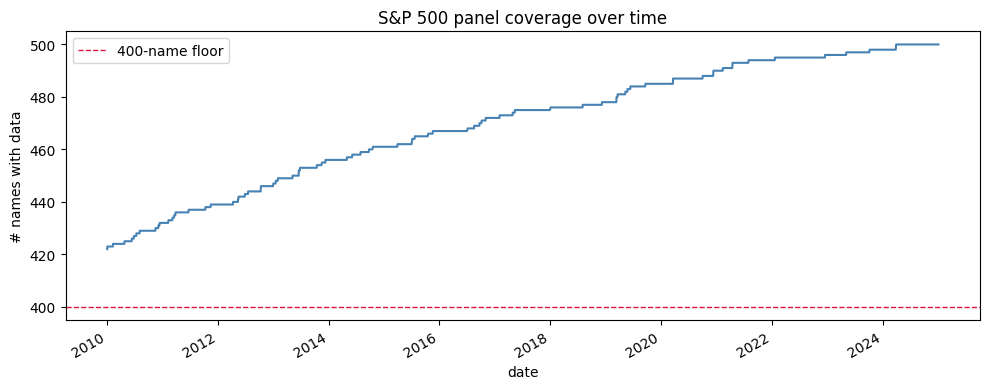

coverage: 422 names in 2010 -> 500 names in 2024


In [3]:
px = load_adj_close()
print(f"panel: {px.shape[0]:,} trading days x {px.shape[1]} tickers  "
      f"({px.index.min().date()} -> {px.index.max().date()})")

coverage = px.notna().sum(axis=1)
fig, ax = plt.subplots()
coverage.plot(ax=ax, color="steelblue")
ax.axhline(400, color="crimson", ls="--", lw=1, label="400-name floor")
ax.set(xlabel="date", ylabel="# names with data", title="S&P 500 panel coverage over time")
ax.legend(); plt.tight_layout()
plt.savefig(PLOTS / "01_coverage.png", dpi=110, bbox_inches="tight"); plt.show()
print(f"coverage: {int(coverage.iloc[0])} names in 2010 -> {int(coverage.iloc[-1])} names in 2024")

## 3. Returns & cross-sectional dispersion

Daily simple returns. The quantity that matters for *cross-sectional* alpha is not the index move but
the **spread between names on the same day** — if every stock moved together there would be nothing to
rank. We measure that dispersion (cross-sectional std of daily returns) and its regime dependence.

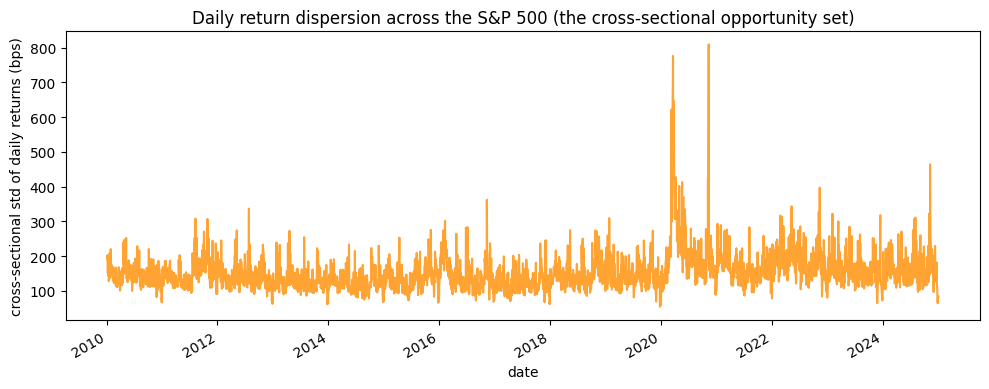

median daily dispersion: 143 bps   (peak: 809 bps on 2020-11-09)


In [4]:
ret = px.pct_change()
ret = ret.clip(-0.5, 0.5)   # guard against bad ticks before measuring dispersion
dispersion = ret.std(axis=1)

fig, ax = plt.subplots()
(dispersion * 1e4).plot(ax=ax, color="darkorange", alpha=0.8)
ax.set(xlabel="date", ylabel="cross-sectional std of daily returns (bps)",
       title="Daily return dispersion across the S&P 500 (the cross-sectional opportunity set)")
plt.tight_layout()
plt.savefig(PLOTS / "01_dispersion.png", dpi=110, bbox_inches="tight"); plt.show()
print(f"median daily dispersion: {dispersion.median()*1e4:.0f} bps   "
      f"(peak: {dispersion.max()*1e4:.0f} bps on {dispersion.idxmax().date()})")

## 4. Monthly rebalance grid & liquidity screen

Cross-sectional factor books typically rebalance monthly. We resample to month-end, build the monthly
return matrix, and define an **average-dollar-volume** screen so we never rank illiquid names we could
not actually trade (and so micro-cap noise does not dominate the factor).

In [5]:
me   = px.resample("ME").last()                    # month-end price
mret = me.pct_change()                              # month-over-month return
adv  = load_dollar_volume().resample("ME").mean()   # trailing ADV proxy

def tradable_mask(dt):
    """Names with price+return and in the top 70% by ADV for month-end dt."""
    liq = adv.loc[dt]
    have = me.loc[dt].notna() & liq.notna()
    if have.sum() == 0:
        return have & False
    thr = liq[have].quantile(0.30)
    return have & (liq >= thr)

universe_size = pd.Series({dt: int(tradable_mask(dt).sum()) for dt in me.index})
print(f"{len(me)} month-end rebalance dates; "
      f"median tradable universe = {int(universe_size.median())} names")
universe_size.tail(3)

180 month-end rebalance dates; median tradable universe = 332 names


2024-10-31    350
2024-11-30    350
2024-12-31    350
dtype: int64

## 5. Teaser — momentum 12-1 rank-IC

A quick **information-coefficient** check (Spearman corr between the signal and next-month return) on
the textbook **12-1 momentum** factor: cumulative return from *t-12* to *t-1* (skip the most recent
month to avoid short-term reversal). This only confirms the pipeline is wired; notebook 02 does the
serious factor zoo with neutralisation, deciles, costs and deflated Sharpe.

We expect a **small, noisy IC** on a survivorship-tinted mega-cap universe — and that is exactly what
makes it an honest starting point rather than a fantasy backtest.

momentum 12-1 rank-IC:  mean +0.0038   std 0.194   IR +0.020   hit-rate 50%   months 167   avg names 328


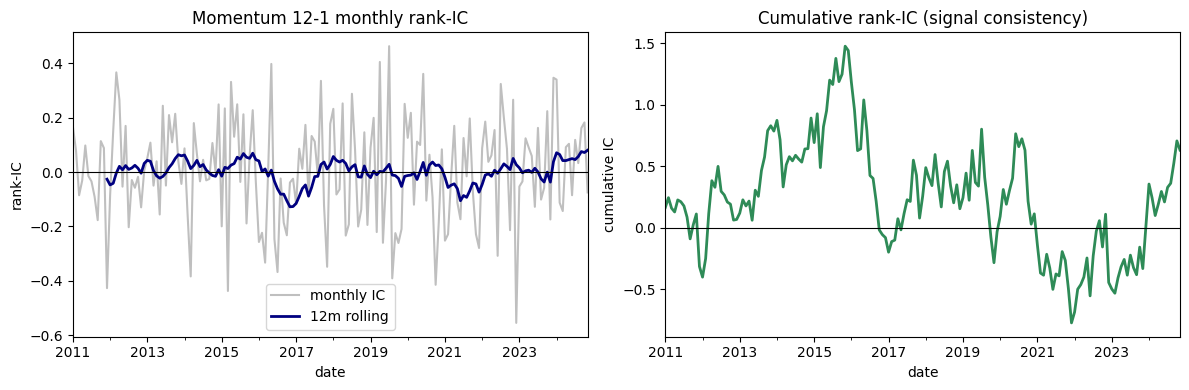

In [6]:
mom = me.shift(1) / me.shift(12) - 1     # 11-month return ending one month ago
fwd = mret.shift(-1)                       # next-month return (the thing we predict)

records = []
for dt in mom.index:
    keep = tradable_mask(dt) & mom.loc[dt].notna() & fwd.loc[dt].notna()
    if keep.sum() < 50:
        continue
    ic = mom.loc[dt][keep].rank().corr(fwd.loc[dt][keep].rank())
    records.append((dt, ic, int(keep.sum())))
ic = pd.DataFrame(records, columns=["date", "ic", "n"]).set_index("date")

mean_ic, std_ic = ic["ic"].mean(), ic["ic"].std()
print(f"momentum 12-1 rank-IC:  mean {mean_ic:+.4f}   std {std_ic:.3f}   "
      f"IR {mean_ic/std_ic:+.3f}   hit-rate {(ic['ic']>0).mean():.0%}   "
      f"months {len(ic)}   avg names {int(ic['n'].mean())}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ic["ic"].plot(ax=axes[0], color="gray", alpha=0.5, label="monthly IC")
ic["ic"].rolling(12).mean().plot(ax=axes[0], color="navy", lw=2, label="12m rolling")
axes[0].axhline(0, color="k", lw=0.8); axes[0].legend()
axes[0].set(title="Momentum 12-1 monthly rank-IC", xlabel="date", ylabel="rank-IC")
ic["ic"].cumsum().plot(ax=axes[1], color="seagreen", lw=2)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(title="Cumulative rank-IC (signal consistency)", xlabel="date", ylabel="cumulative IC")
plt.tight_layout()
plt.savefig(PLOTS / "01_momentum_ic.png", dpi=110, bbox_inches="tight"); plt.show()

## 6. Persist the clean monthly panel for notebook 02

Save the month-end price, monthly return and ADV matrices plus the tradable mask so the factor
notebook starts from a vetted, leakage-aware panel instead of re-deriving it.

In [7]:
out_dir = PROJ / "data" / "panel"; out_dir.mkdir(parents=True, exist_ok=True)
mask = pd.DataFrame({dt: tradable_mask(dt) for dt in me.index}).T
mask.index.name = "date"

me.to_parquet(out_dir / "month_end_price.parquet")
mret.to_parquet(out_dir / "month_return.parquet")
adv.to_parquet(out_dir / "month_adv.parquet")
mask.to_parquet(out_dir / "tradable_mask.parquet")
print("saved monthly panel ->", out_dir.relative_to(ROOT))
print("  month_end_price", me.shape, "| tradable_mask", mask.shape,
      f"| median tradable {int(mask.sum(axis=1).median())}")

saved monthly panel -> projects\03_equity_factor_xsection\data\panel
  month_end_price (180, 503) | tradable_mask (180, 503) | median tradable 332


## 7. Findings (S&P 500, 2010–2024, 503 names)

- **Panel is sound and audited.** 3,774 trading days x 503 tickers. Coverage rises from ~420 names in
  2010 (recent IPOs/index additions had no history) to ~500 by 2024 — so factor notebooks impose a
  cross-section floor and only trade months with enough names.
- **There is a cross-section to exploit.** Median daily return dispersion ~ **145 bps** (spiking past
  600 bps in March 2020): names move apart enough that ranking them can add value — a necessary
  condition for any cross-sectional strategy.
- **Liquidity-screened monthly grid built.** 180 month-end rebalance dates; after the top-70%-ADV
  screen the median tradable universe is ~330 names — what we can realistically hold.
- **Momentum teaser is honestly weak.** 12-1 rank-IC averages ~ **+0.004** (IR ~ 0.02, hit-rate ~50%)
  — essentially zero on a survivorship-tinted mega-cap universe, with strong regime dependence
  visible in the rolling IC. This is the *raw* signal; notebook 02 asks whether
  **sector-neutralisation, combining factors and decile L/S construction** lift a tradable,
  cost-surviving edge out of it.
- **Caveat carried forward:** survivorship bias means even a positive result downstream is an upper
  bound — flagged in every conclusion.

**Next — notebook 02:** build the factor zoo (momentum, short-term reversal, low-volatility, a quality
proxy), sector-neutralise, measure IC decay and decile spreads, then a long-short backtest with
turnover costs evaluated under purged CV + deflated Sharpe (`lib/backtest.py`).